In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

In [12]:
files = {
    "VIIRS_J1":  r"D:\mo&Se\New folder (2)\small_dataset1.csv",
    "MODIS":     r"D:\mo&Se\New folder (2)\small_dataset2.csv",
    "VIIRS_SNPP":r"D:\mo&Se\New folder (2)\small_dataset3.csv",
}
dtypes = {
    "latitude": "float32",
    "longitude": "float32",
    "brightness": "float32",
    "scan": "float32",
    "track": "float32",
    "acq_time": "int32",
    "satellite": "category",
    "instrument": "category",
    "confidence": "category",
    "version": "category",
    "bright_t31": "float32",
    "frp": "float32",
    "daynight": "category",
}




In [15]:
CHUNKSIZE = 100_000

# chunked, single-pass aggregation
# Each file is streamed in pieces; running totals are updated per chunk
# instead of holding data 1 + data 2 + data 3 + a concatenated data's all at once.
row_counts = {}
frp_sum, frp_sumsq, frp_count, frp_min, frp_max = {}, {}, {}, {}, {}
daynight_counts = {}
monthly_counts = {}
missing_counts = {}

rng = np.random.default_rng(42)
RES_SIZE = 15_000
reservoirs = {}   # bounded sample per source, used only for plotting later

for source, path in files.items():
    n_rows = 0
    fsum = fsumsq = 0.0
    fcount = 0
    fmin, fmax = np.inf, -np.inf
    dn_counts = {}
    m_counts = {}
    miss = None
    reservoir = []
    seen = 0

    for chunk in pd.read_csv(path, dtype=dtypes, parse_dates=["acq_date"],
                              chunksize=CHUNKSIZE):
        n_rows += len(chunk)

        vals = chunk["frp"].dropna().to_numpy(dtype="float64")
        if vals.size:
            fsum += vals.sum()
            fsumsq += (vals ** 2).sum()
            fcount += vals.size
            fmin = min(fmin, vals.min())
            fmax = max(fmax, vals.max())

        vc = chunk["daynight"].value_counts()
        for k, v in vc.items():
            dn_counts[k] = dn_counts.get(k, 0) + int(v)

        months = chunk["acq_date"].dt.to_period("M").astype(str)
        vc = months.value_counts()
        for k, v in vc.items():
            m_counts[k] = m_counts.get(k, 0) + int(v)

        chunk_missing = chunk.isna().sum()
        miss = chunk_missing if miss is None else miss.add(chunk_missing, fill_value=0)

        # bounded reservoir sample, used only for plots (not full data storage)
        sample_cols = chunk[["latitude", "longitude", "frp"]].dropna().to_numpy(dtype="float64")
        for row in sample_cols:
            seen += 1
            if len(reservoir) < RES_SIZE:
                reservoir.append(row)
            else:
                j = rng.integers(0, seen)
                if j < RES_SIZE:
                    reservoir[j] = row

        del chunk, vals, sample_cols
        gc.collect()

    row_counts[source] = n_rows
    frp_sum[source], frp_sumsq[source], frp_count[source] = fsum, fsumsq, fcount
    frp_min[source], frp_max[source] = fmin, fmax
    daynight_counts[source] = dn_counts
    monthly_counts[source] = m_counts
    missing_counts[source] = miss
    reservoirs[source] = np.array(reservoir)

print("Row counts:", row_counts)

Row counts: {'VIIRS_J1': 311495, 'MODIS': 301472, 'VIIRS_SNPP': 319343}


In [16]:
# FRP summary stats, computed from the accumulated sums (no raw column ever fully materialized for this calculation)
frp_summary = pd.DataFrame({
    "count": frp_count,
    "mean": {s: frp_sum[s] / frp_count[s] for s in files},
    "std": {s: ((frp_sumsq[s] / frp_count[s]) - (frp_sum[s] / frp_count[s]) ** 2) ** 0.5 for s in files},
    "min": frp_min,
    "max": frp_max,
})
frp_summary


,count,mean,std,min,max
VIIRS_J1,311495,8.286232,16.959886,0.0,3276.550049
MODIS,301472,34.616751,81.547616,0.0,6927.350098
VIIRS_SNPP,319343,8.089777,14.314163,0.0,784.969971


In [17]:
# missing values per source (already accumulated, reused as-is, not recomputed from raw data)
pd.DataFrame(missing_counts).T

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
VIIRS_J1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MODIS,0,0,0,0,0,0,0,0,0,0,0,0,0,0
VIIRS_SNPP,0,0,0,0,0,0,0,0,0,0,0,0,0,0


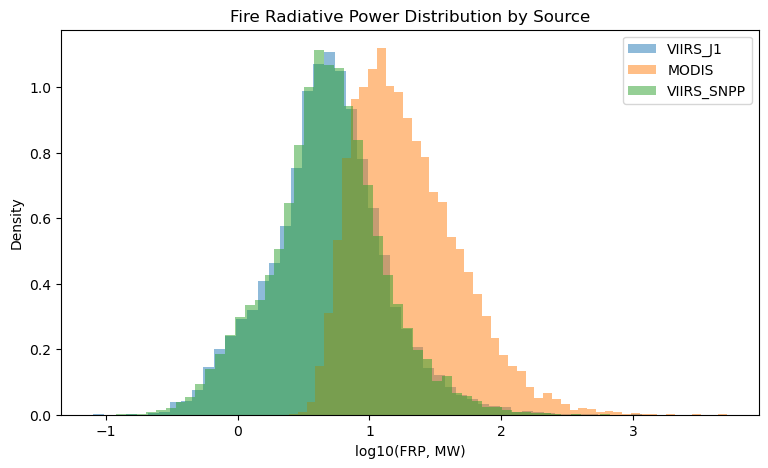

In [18]:
# FRP distribution plot (built once from the reservoir samples)
plt.figure(figsize=(9, 5))
for source, arr in reservoirs.items():
    vals = arr[:, 2]
    vals = vals[vals > 0]
    plt.hist(np.log10(vals), bins=50, alpha=0.5, label=source, density=True)
plt.xlabel("log10(FRP, MW)")
plt.ylabel("Density")
plt.title("Fire Radiative Power Distribution by Source")
plt.legend()
plt.show()


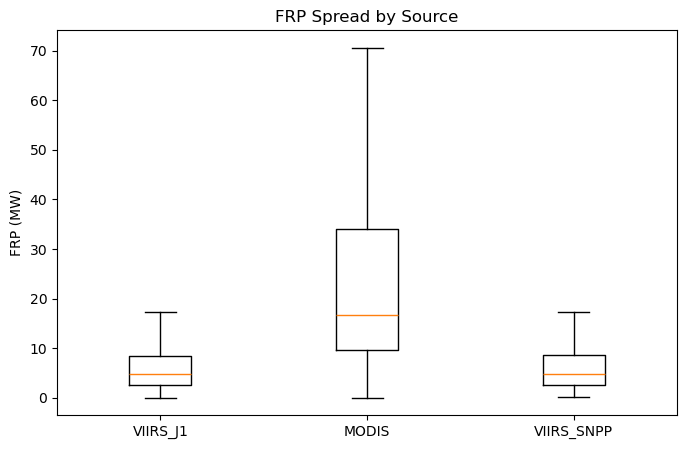

In [19]:
# boxplot comparison
plt.figure(figsize=(8, 5))
plt.boxplot([reservoirs[s][:, 2] for s in files], tick_labels=list(files.keys()),
            showfliers=False)
plt.ylabel("FRP (MW)")
plt.title("FRP Spread by Source")
plt.show()

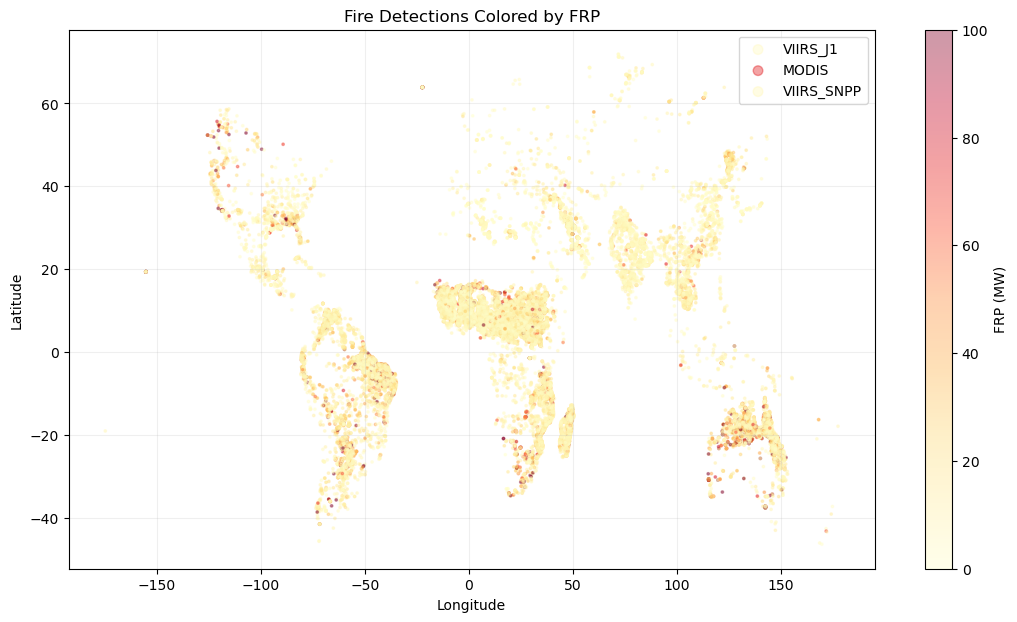

In [20]:
# fire locations on a map, colored by FRP
plt.figure(figsize=(13, 7))
for source, arr in reservoirs.items():
    plt.scatter(arr[:, 1], arr[:, 0], c=arr[:, 2], cmap="YlOrRd",
                vmin=0, vmax=100, s=3, alpha=0.4, label=source)
plt.colorbar(label="FRP (MW)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire Detections Colored by FRP")
plt.legend(markerscale=4)
plt.grid(alpha=0.2)
plt.show()

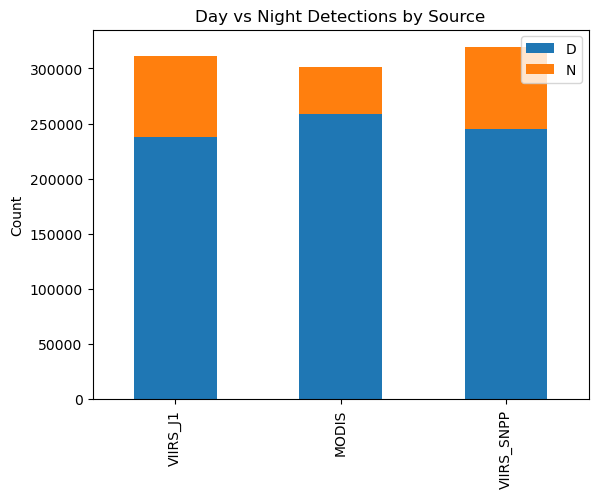

In [21]:
# day vs night counts
pd.DataFrame(daynight_counts).T.plot(kind="bar", stacked=True)
plt.title("Day vs Night Detections by Source")
plt.ylabel("Count")
plt.show()


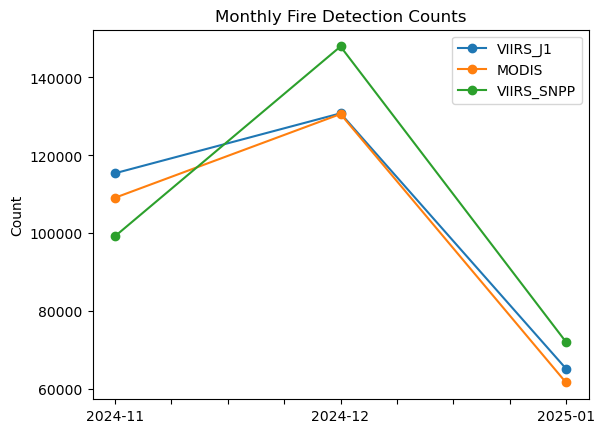

In [22]:
# monthly trend 
pd.DataFrame(monthly_counts).sort_index().plot(marker="o")
plt.title("Monthly Fire Detection Counts")
plt.ylabel("Count")
plt.show()